In [1]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.datasets import ImageFolder
from torchvision.models import resnet50, ResNet50_Weights
from torch.utils.data import DataLoader, random_split

import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cpu


In [2]:
dataset_path = r'C:\Users\tejal\OneDrive\Desktop\imageprocessing\MRIDATASETT'

In [3]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
print('Transforms ready.')

Transforms ready.


In [4]:
train_path = os.path.join(dataset_path, 'Training')
test_path  = os.path.join(dataset_path, 'Testing')

if os.path.exists(train_path) and os.path.exists(test_path):
    train_dataset = ImageFolder(train_path, transform=transform)
    test_dataset  = ImageFolder(test_path,  transform=transform)
    print('Loaded pre-split folders.')
else:
    full_dataset = ImageFolder(dataset_path, transform=transform)
    train_size   = int(0.8 * len(full_dataset))
    test_size    = len(full_dataset) - train_size
    train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])
    print('Used random 80/20 split.')

print('Train images:', len(train_dataset))
print('Test images :', len(test_dataset))

Loaded pre-split folders.
Train images: 5712
Test images : 1311


In [5]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False)
print('DataLoaders ready.')

DataLoaders ready.


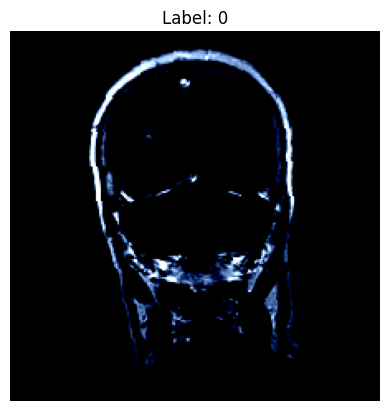

In [6]:
images, labels = next(iter(train_loader))
plt.imshow(images[0].permute(1, 2, 0).numpy().clip(0, 1))
plt.title(f'Label: {labels[0].item()}')
plt.axis('off')
plt.show()

In [7]:
model = resnet50(weights=ResNet50_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False

num_features = model.fc.in_features
num_classes = len(train_dataset.classes)
print("Number of classes:", num_classes)
model.fc = nn.Linear(num_features, num_classes)

for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(device)
print('Model ready.')

Number of classes: 4
Model ready.


In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.0001)
print('Criterion and optimizer ready.')

Criterion and optimizer ready.


In [ ]:
epochs = 5
print('Training started...\n')

for epoch in range(epochs):

    # Training phase
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss    = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    # Validation phase
    model.eval()
    correct = 0
    total   = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images  = images.to(device)
            labels  = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total   += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f'Epoch {epoch+1}/{epochs}  |  Loss: {avg_loss:.4f}  |  Accuracy: {accuracy:.2f}%')

print('\nTraining finished!')

Training started...



In [ ]:
torch.save(model.state_dict(), 'tumor_model.pth')
print('Model saved as tumor_model.pth')

In [ ]:
gradients  = []
activations = []

def save_gradient(module, grad_input, grad_output):
    gradients.clear()
    gradients.append(grad_output[0])

def save_activation(module, input, output):
    activations.clear()
    activations.append(output)

target_layer = model.layer4[-1]
target_layer.register_forward_hook(save_activation)
target_layer.register_backward_hook(save_gradient)
print('Grad-CAM hooks registered.')

In [ ]:
def generate_gradcam(image_path):
    img      = Image.open(image_path).convert('RGB')
    original = np.array(img.resize((224, 224)))

    input_tensor = transform(img).unsqueeze(0).to(device)

    model.eval()
    output = model(input_tensor)
    pred   = output.argmax()

    model.zero_grad()
    output[0, pred].backward()

    grad    = gradients[0].cpu().data.numpy()[0]
    act     = activations[0].cpu().data.numpy()[0]
    weights = np.mean(grad, axis=(1, 2))

    cam = np.zeros(act.shape[1:], dtype=np.float32)
    for i, w in enumerate(weights):
        cam += w * act[i]

    cam = np.maximum(cam, 0)
    cam = cam / (cam.max() + 1e-8)   # FIXED: avoid divide-by-zero
    cam = cv2.resize(cam, (224, 224))

    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(original, 0.6, heatmap, 0.4, 0)

    return overlay, pred.item()

print('generate_gradcam() ready.')

In [ ]:
def generate_explanation(pred):
    if pred == 1:
        return (
            'The model detected patterns associated with brain tumor tissue. '
            'The highlighted regions in the heatmap show where the model focused. '
            'Please consult a medical professional for a proper diagnosis.'
        )
    else:
        return (
            'The model found no strong indicators of a brain tumor in this scan. '
            'The scan appears within normal range based on the training data. '
            'Always verify results with a qualified doctor.'
        )

print('generate_explanation() ready.')

In [ ]:
def predict(image_path):
    model.eval()
    with torch.no_grad():
        img    = Image.open(image_path).convert('RGB')
        tensor = transform(img).unsqueeze(0).to(device)
        output = model(tensor)
        pred   = output.argmax().item()

    overlay, _  = generate_gradcam(image_path)
    explanation = generate_explanation(pred)

    return pred, overlay, explanation

print('predict() ready.')

In [ ]:
test_image = 'test_mri.jpg'

if not os.path.exists(test_image):
    print(f"ERROR: '{test_image}' not found.")
    print("Place a test MRI image named 'test_mri.jpg' in the same folder as this notebook.")
else:
    prediction, heatmap, explanation = predict(test_image)

    print('Prediction:', 'Tumor' if prediction == 1 else 'No Tumor')

    plt.figure(figsize=(6, 6))
    plt.imshow(heatmap)
    plt.title(f"Grad-CAM — {'Tumor' if prediction == 1 else 'No Tumor'}")
    plt.axis('off')
    plt.show()

    print('\nExplanation:')
    print(explanation)